# Experiment: PPO Curriculum Experiments

Objective:
- Comparar como a ordem dos oponentes (`random`, `heuristic`, `self-play`) influencia a aprendizagem do `PPO`.
- Manter o mesmo orcamento total de episodios em todas as agendas.
- Incluir uma variante de co-treino dual, onde dois modelos `PPO` aprendem em simultaneo jogando um contra o outro.
- Registar metricas e notas ao longo da experiencia, em vez de olhar apenas para o melhor checkpoint final.


## Hipoteses e agendas

Hipoteses desta segunda iteracao:
- blocos heurísticos longos estao a ser demasiado destrutivos para o PPO atual;
- um bloco curto de `heuristic` pode funcionar melhor como sonda de dificuldade do que como fase principal;
- uma transicao probabilistica para `self-play` pode ser mais estavel do que uma troca rigida de fase;
- o co-treino dual continua a ser a linha mais promissora, mas deve ser reavaliado com varias seeds.

Agendas de segunda geracao sugeridas:
- `curriculum_mid_self`
- `curriculum_short_heuristic_mid`
- `curriculum_short_heuristic_late`
- `curriculum_probabilistic_bridge`
- `co_training_dual`


In [1]:
from __future__ import annotations

import copy
import json
import statistics
import sys
from pathlib import Path

import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve().parents[0] if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from connect4_rl.agents.learning import PPOAgent
from connect4_rl.config import load_config
from connect4_rl.experiments import compute_elo_ratings, round_robin_detailed
from connect4_rl.experiments.ppo_curriculum import (
    build_default_ppo_curricula,
    expand_curriculum_schedule,
    train_dual_ppo_co_training,
    train_ppo_with_curriculum,
)

base_config = load_config(str(ROOT / 'config.yaml'))
curricula = build_default_ppo_curricula()
print('Curricula disponiveis:', ', '.join(curricula.keys()))


✓ Configuration validated successfully
Curricula disponiveis: curriculum_basic, curriculum_mid_self, curriculum_late_heuristic, curriculum_short_heuristic_mid, curriculum_short_heuristic_late, curriculum_probabilistic_bridge, co_training_dual


## Configuracao da experiencia

Ajusta esta celula antes de correr. O importante e manter o mesmo `episodes` entre agendas para isolar o efeito da ordem dos oponentes.


In [2]:
EXPERIMENT_EPISODES = 180
EVAL_INTERVAL = 30
EVAL_GAMES = 12
SEEDS = [7, 17, 27]
SELECTED_AGENDAS = [
    'curriculum_mid_self',
    'curriculum_short_heuristic_mid',
    'curriculum_short_heuristic_late',
    'curriculum_probabilistic_bridge',
    'co_training_dual',
]
OUTPUT_ROOT = ROOT / 'outputs' / 'ppo_curriculum_experiments_v2'
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)


def make_config(seed: int):
    config = copy.deepcopy(base_config)
    config.global_.seed = seed
    config.ppo.episodes = EXPERIMENT_EPISODES
    config.ppo.eval_interval = EVAL_INTERVAL
    config.ppo.eval_games = EVAL_GAMES
    return config

print({
    'episodes': EXPERIMENT_EPISODES,
    'eval_interval': EVAL_INTERVAL,
    'eval_games': EVAL_GAMES,
    'seeds': SEEDS,
    'agendas': SELECTED_AGENDAS,
})


{'episodes': 180, 'eval_interval': 30, 'eval_games': 12, 'seeds': [7, 17, 27], 'agendas': ['curriculum_mid_self', 'curriculum_short_heuristic_mid', 'curriculum_short_heuristic_late', 'curriculum_probabilistic_bridge', 'co_training_dual']}


## Verificacao do calendario por agenda

Antes de correr, vale a pena confirmar quantos episodios vao para cada fase.


In [3]:
for agenda_name in SELECTED_AGENDAS:
    definition = curricula[agenda_name]
    if agenda_name == 'co_training_dual':
        print(f'\n{agenda_name}: co-treino dual durante {EXPERIMENT_EPISODES} episodios')
        continue
    schedule, phase_summary = expand_curriculum_schedule(EXPERIMENT_EPISODES, definition, seed=SEEDS[0])
    print(f'\n{agenda_name}')
    for phase in phase_summary:
        print(phase)



curriculum_mid_self
{'phase_name': 'warmup_random', 'opponent_kind': 'random', 'episodes': 45, 'start_episode': 1, 'end_episode': 45, 'realized_opponents': {'random': 45}}
{'phase_name': 'early_self_play', 'opponent_kind': 'self_play', 'episodes': 45, 'start_episode': 46, 'end_episode': 90, 'realized_opponents': {'self_play': 45}}
{'phase_name': 'mid_heuristic', 'opponent_kind': 'heuristic', 'episodes': 45, 'start_episode': 91, 'end_episode': 135, 'realized_opponents': {'heuristic': 45}}
{'phase_name': 'final_self_play', 'opponent_kind': 'self_play', 'episodes': 45, 'start_episode': 136, 'end_episode': 180, 'realized_opponents': {'self_play': 45}}

curriculum_short_heuristic_mid
{'phase_name': 'warmup_random', 'opponent_kind': 'random', 'episodes': 45, 'start_episode': 1, 'end_episode': 45, 'realized_opponents': {'random': 45}}
{'phase_name': 'self_play_growth', 'opponent_kind': 'self_play', 'episodes': 63, 'start_episode': 46, 'end_episode': 108, 'realized_opponents': {'self_play': 6

## Execucao multi-seed

Esta celula corre todas as agendas para todas as seeds indicadas. O objetivo agora nao e tirar conclusoes com uma seed so, mas perceber estabilidade e variancia.


In [4]:
results = {}

for agenda_name in SELECTED_AGENDAS:
    results[agenda_name] = {}
    for seed in SEEDS:
        config = make_config(seed=seed)
        checkpoint_dir = OUTPUT_ROOT / agenda_name / f'seed_{seed}'
        print(f'\n=== Running {agenda_name} | seed={seed} ===')

        if agenda_name == 'co_training_dual':
            agents, metrics = train_dual_ppo_co_training(config, checkpoint_dir=checkpoint_dir)
            results[agenda_name][seed] = {
                'kind': 'dual',
                'agents': agents,
                'metrics': metrics,
            }
            print('Agent A last eval:', metrics.agent_a.evaluation[-1] if metrics.agent_a.evaluation else {})
            print('Agent B last eval:', metrics.agent_b.evaluation[-1] if metrics.agent_b.evaluation else {})
            print('Head-to-head:', metrics.head_to_head_win_rate_a[-1] if metrics.head_to_head_win_rate_a else {})
        else:
            definition = curricula[agenda_name]
            agent, metrics = train_ppo_with_curriculum(definition, config, checkpoint_dir=checkpoint_dir)
            results[agenda_name][seed] = {
                'kind': 'single',
                'agent': agent,
                'metrics': metrics,
            }
            print('Last eval:', metrics.evaluation[-1] if metrics.evaluation else {})



=== Running curriculum_mid_self | seed=7 ===
✓ All random seeds set to 7
Last eval: {'episode': 180.0, 'vs_random_win_rate': 0.9166666666666666, 'vs_heuristic_win_rate': 0.0, 'vs_previous_win_rate': 0.5}

=== Running curriculum_mid_self | seed=17 ===
✓ All random seeds set to 17
Last eval: {'episode': 180.0, 'vs_random_win_rate': 0.75, 'vs_heuristic_win_rate': 0.0, 'vs_previous_win_rate': 1.0}

=== Running curriculum_mid_self | seed=27 ===
✓ All random seeds set to 27
Last eval: {'episode': 180.0, 'vs_random_win_rate': 0.8333333333333334, 'vs_heuristic_win_rate': 0.0, 'vs_previous_win_rate': 0.0}

=== Running curriculum_short_heuristic_mid | seed=7 ===
✓ All random seeds set to 7
Last eval: {'episode': 180.0, 'vs_random_win_rate': 0.9166666666666666, 'vs_heuristic_win_rate': 0.0, 'vs_previous_win_rate': 0.5}

=== Running curriculum_short_heuristic_mid | seed=17 ===
✓ All random seeds set to 17
Last eval: {'episode': 180.0, 'vs_random_win_rate': 0.75, 'vs_heuristic_win_rate': 0.0, 'vs_

## Resumo agregado por agenda

Esta tabela curta resume a media das metricas finais por agenda. Para o `co_training_dual`, mostramos `agent_a` e `agent_b` separadamente.


In [5]:
summary_rows = []
for agenda_name, seed_payloads in results.items():
    sample_payload = next(iter(seed_payloads.values()))
    if sample_payload['kind'] == 'single':
        final_random = []
        final_heuristic = []
        best_scores = []
        for seed, payload in seed_payloads.items():
            metrics = payload['metrics']
            last_eval = metrics.evaluation[-1] if metrics.evaluation else {}
            final_random.append(float(last_eval.get('vs_random_win_rate', 0.0)))
            final_heuristic.append(float(last_eval.get('vs_heuristic_win_rate', 0.0)))
            best_scores.append(float(metrics.best_score))
        summary_rows.append({
            'agenda': agenda_name,
            'model': 'single',
            'mean_vs_random': round(statistics.fmean(final_random), 4),
            'mean_vs_heuristic': round(statistics.fmean(final_heuristic), 4),
            'mean_best_score': round(statistics.fmean(best_scores), 4),
        })
    else:
        for model_key in ['agent_a', 'agent_b']:
            final_random = []
            final_heuristic = []
            best_scores = []
            for seed, payload in seed_payloads.items():
                metrics = payload['metrics']
                agent_metrics = getattr(metrics, model_key)
                last_eval = agent_metrics.evaluation[-1] if agent_metrics.evaluation else {}
                final_random.append(float(last_eval.get('vs_random_win_rate', 0.0)))
                final_heuristic.append(float(last_eval.get('vs_heuristic_win_rate', 0.0)))
                best_scores.append(float(agent_metrics.best_score))
            summary_rows.append({
                'agenda': agenda_name,
                'model': model_key,
                'mean_vs_random': round(statistics.fmean(final_random), 4),
                'mean_vs_heuristic': round(statistics.fmean(final_heuristic), 4),
                'mean_best_score': round(statistics.fmean(best_scores), 4),
            })

for row in summary_rows:
    print(row)


{'agenda': 'curriculum_mid_self', 'model': 'single', 'mean_vs_random': 0.8333, 'mean_vs_heuristic': 0.0, 'mean_best_score': 0.9444}
{'agenda': 'curriculum_short_heuristic_mid', 'model': 'single', 'mean_vs_random': 0.8611, 'mean_vs_heuristic': 0.0, 'mean_best_score': 0.9444}
{'agenda': 'curriculum_short_heuristic_late', 'model': 'single', 'mean_vs_random': 0.8333, 'mean_vs_heuristic': 0.0833, 'mean_best_score': 1.25}
{'agenda': 'curriculum_probabilistic_bridge', 'model': 'single', 'mean_vs_random': 0.8333, 'mean_vs_heuristic': 0.0, 'mean_best_score': 1.0556}
{'agenda': 'co_training_dual', 'model': 'agent_a', 'mean_vs_random': 0.8611, 'mean_vs_heuristic': 0.0, 'mean_best_score': 1.2222}
{'agenda': 'co_training_dual', 'model': 'agent_b', 'mean_vs_random': 0.7778, 'mean_vs_heuristic': 0.0, 'mean_best_score': 1.2222}


## Curvas por seed para agendas simples

Estas curvas ajudam a perceber estabilidade entre seeds. O objetivo nao e so a media, mas tambem a dispersao.


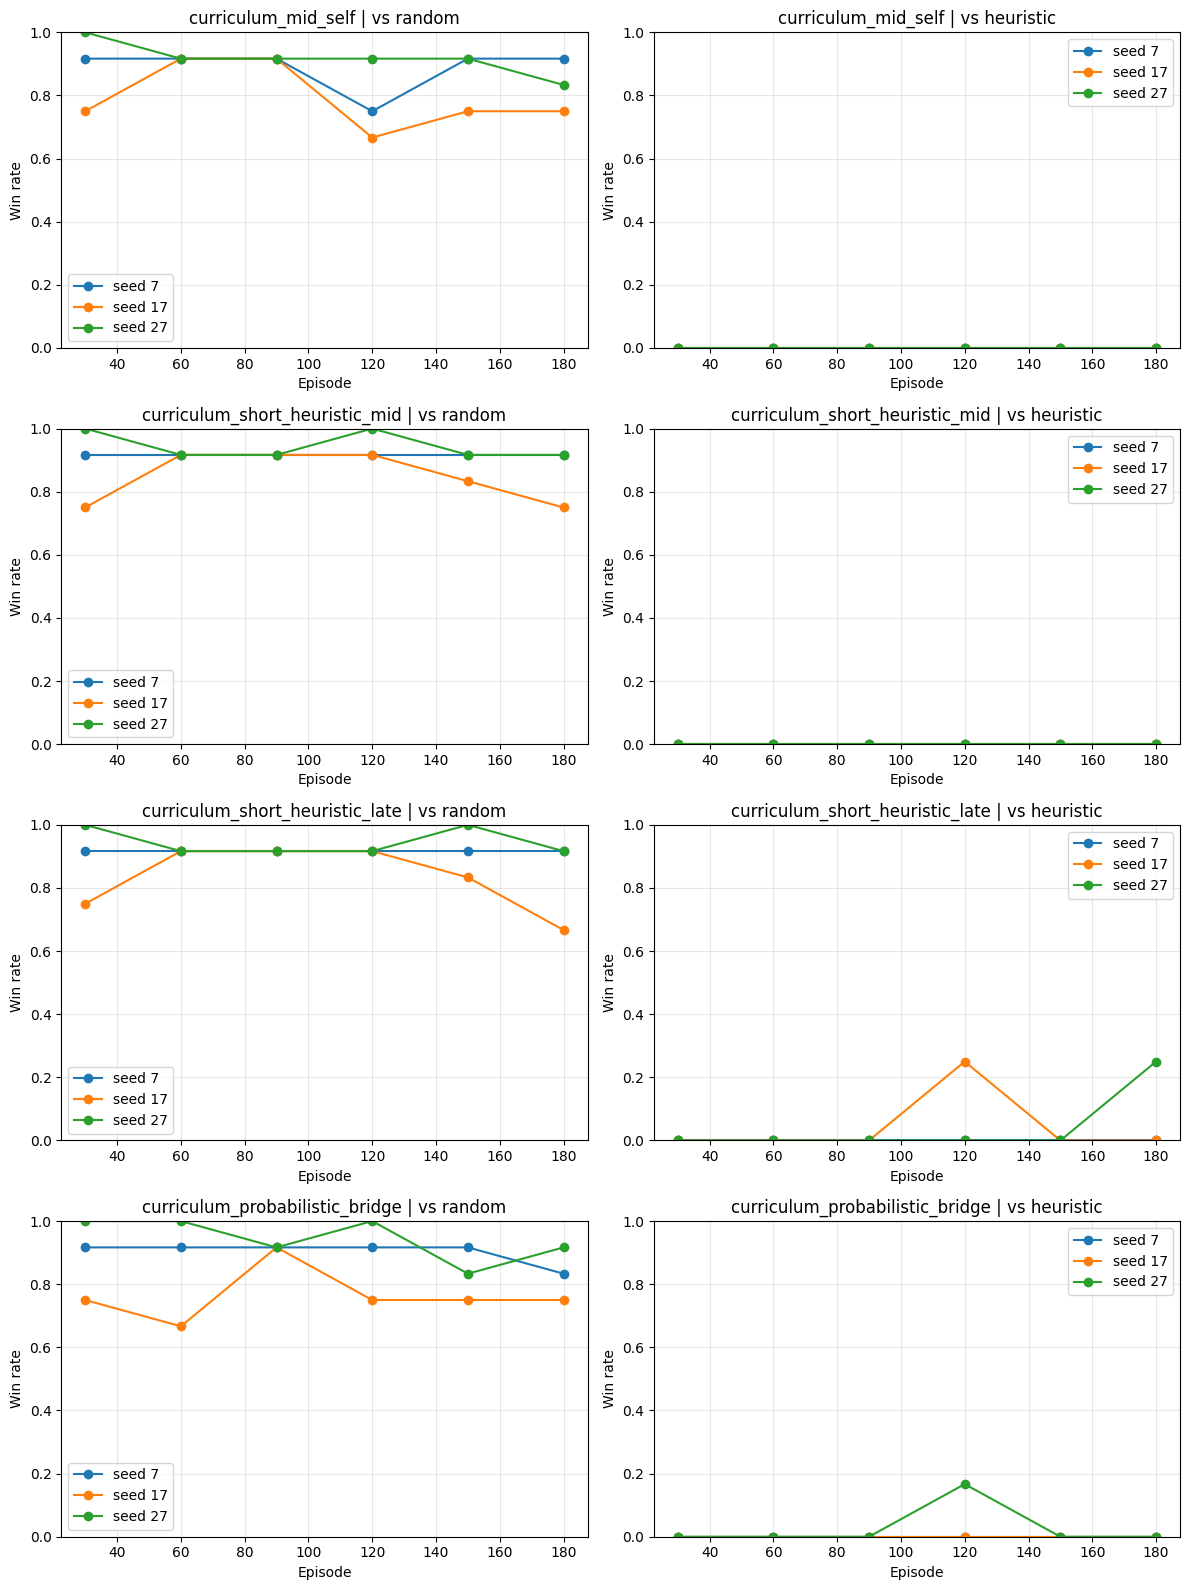

In [6]:
fig, axes = plt.subplots(len([a for a in SELECTED_AGENDAS if a != 'co_training_dual']), 2, figsize=(12, 4 * max(1, len([a for a in SELECTED_AGENDAS if a != 'co_training_dual']))))
axes = axes if hasattr(axes, 'ndim') else [axes]
non_dual_agendas = [agenda for agenda in SELECTED_AGENDAS if agenda != 'co_training_dual']

for row_idx, agenda_name in enumerate(non_dual_agendas):
    ax_random = axes[row_idx][0]
    ax_heur = axes[row_idx][1]
    for seed, payload in results[agenda_name].items():
        metrics = payload['metrics']
        episodes = [item['episode'] for item in metrics.evaluation]
        random_wr = [item['vs_random_win_rate'] for item in metrics.evaluation]
        heuristic_wr = [item['vs_heuristic_win_rate'] for item in metrics.evaluation]
        ax_random.plot(episodes, random_wr, marker='o', label=f'seed {seed}')
        ax_heur.plot(episodes, heuristic_wr, marker='o', label=f'seed {seed}')
    ax_random.set_title(f'{agenda_name} | vs random')
    ax_heur.set_title(f'{agenda_name} | vs heuristic')
    for ax in (ax_random, ax_heur):
        ax.set_xlabel('Episode')
        ax.set_ylabel('Win rate')
        ax.set_ylim(0.0, 1.0)
        ax.grid(True, alpha=0.3)
        ax.legend()
plt.tight_layout()


## Torneio final com melhores checkpoints

Esta celula usa os agentes devolvidos por cada corrida. Como a pipeline agora recarrega o melhor checkpoint antes de devolver o agente, esta comparacao passou a ser mais fiavel. Ainda assim, o ideal final e correr um torneio maior e talvez agregá-lo por seed.


In [7]:
for seed in SEEDS:
    print(f'\n### Final tournament | seed={seed}')
    agent_factories = {}
    for agenda_name, seed_payloads in results.items():
        payload = seed_payloads[seed]
        if payload['kind'] == 'single':
            agent = payload['agent']
            agent_factories[agenda_name] = lambda agent=agent: agent
        else:
            agent_a, agent_b = payload['agents']
            agent_factories[f'{agenda_name}_a'] = lambda agent=agent_a: agent
            agent_factories[f'{agenda_name}_b'] = lambda agent=agent_b: agent
    scoreboard, match_log = round_robin_detailed(agent_factories, games_per_pair=8)
    elo = compute_elo_ratings(match_log)
    print('Scoreboard:', json.dumps(scoreboard, indent=2))
    print('Elo:', elo)



### Final tournament | seed=7
Scoreboard: {
  "curriculum_mid_self": {
    "wins": 16.0,
    "games": 40.0,
    "losses": 24.0,
    "win_rate": 0.4,
    "draws": 0.0,
    "draw_rate": 0.0
  },
  "curriculum_short_heuristic_mid": {
    "losses": 16.0,
    "games": 40.0,
    "wins": 24.0,
    "win_rate": 0.6,
    "draws": 0.0,
    "draw_rate": 0.0
  },
  "curriculum_short_heuristic_late": {
    "losses": 20.0,
    "games": 40.0,
    "wins": 20.0,
    "win_rate": 0.5,
    "draws": 0.0,
    "draw_rate": 0.0
  },
  "curriculum_probabilistic_bridge": {
    "losses": 20.0,
    "games": 40.0,
    "wins": 20.0,
    "win_rate": 0.5,
    "draws": 0.0,
    "draw_rate": 0.0
  },
  "co_training_dual_a": {
    "losses": 12.0,
    "games": 40.0,
    "wins": 28.0,
    "win_rate": 0.7,
    "draws": 0.0,
    "draw_rate": 0.0
  },
  "co_training_dual_b": {
    "wins": 12.0,
    "games": 40.0,
    "losses": 28.0,
    "win_rate": 0.3,
    "draws": 0.0,
    "draw_rate": 0.0
  }
}
Elo: {'co_training_dual_a':

## Registo de resultados e notas

Para cada agenda, anota:
- media e desvio entre seeds;
- se o desempenho contra `random` se manteve estavel;
- se houve qualquer ganho contra `heuristic`;
- em que episodio surgiu o melhor checkpoint;
- se o bloco heuristico curto ajudou ou ainda foi demasiado agressivo;
- se a agenda probabilistica foi mais estavel do que as agendas por blocos rigidos.

Perguntas a responder:
- o bloco heuristico curto e melhor do que 25% seguidos?
- a fase mista probabilistica evita colapso?
- o co-treino dual continua a dominar quando repetido com 3 seeds?


## Proximos passos

- se uma agenda simples for claramente melhor, aumentar episodios e jogos de avaliacao;
- se o co-treino dual continuar superior, testar uma versao hibrida com pequena injecao de heuristico;
- comparar seeds para separar efeito real de ruido;
- se ainda nao houver progresso contra `heuristic`, reduzir ainda mais a exposicao ou transformar o heuristico em amostragem rara dentro de self-play.
